In [1]:
# pip install tensorflow datasets pillow 

In [2]:
from datasets import load_dataset
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [3]:
# loading dataset
dataset = load_dataset("mnist")

In [4]:
# Function to save images into folders
def save_split(split, split_name):
    for i in range(10):
        os.makedirs(f"data/mnist_data/{split_name}/{i}", exist_ok=True)

    for idx, example in enumerate(split):
        image = example["image"]  # PIL image
        label = example["label"]
        image.save(f"data/mnist_data/{split_name}/{label}/{idx}.png")

In [5]:
# saving train & test images
save_split(dataset["train"], "train")
save_split(dataset["test"], "test")

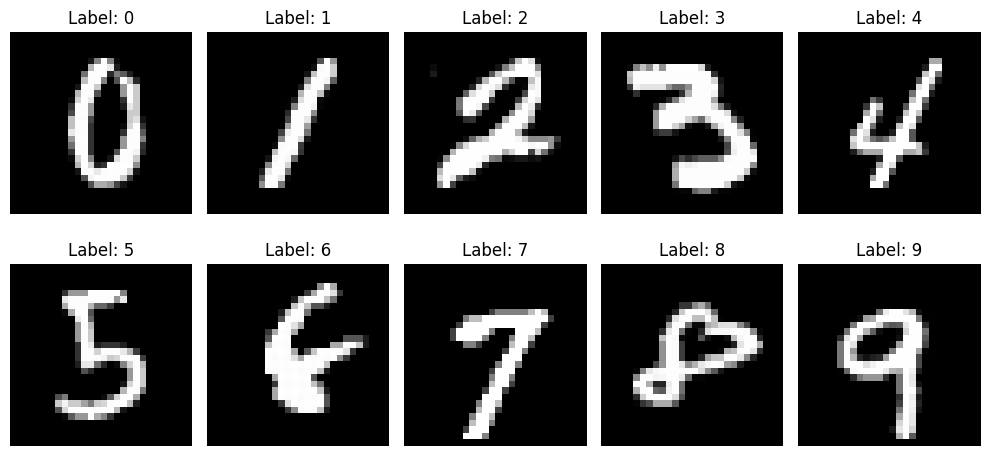

In [6]:
# displaying sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(10):
    label = str(i)
    folder = f"data/mnist_data/train/{label}"
    img_file = random.choice(os.listdir(folder))
    
    img = Image.open(os.path.join(folder, img_file))
    
    ax = axes[i // 5, i % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# loading data using keras
img_size = 28
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "data/mnist_data/train",
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    "data/mnist_data/test",
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical"
)

Found 60000 images belonging to 10 classes.
Found 10000 images belonging to 10 classes.


In [8]:
# defining CNN model
model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    # block 1
    layers.Conv2D(16, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    
    # block 2
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    # block 3
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 800)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         102,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 108,618 (424.29 KB)

 Trainable params: 108,618 (424.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# compiling the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
# training the model
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9529 - loss: 0.1575 - val_accuracy: 0.9854 - val_loss: 0.0462
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9839 - loss: 0.0520 - val_accuracy: 0.9873 - val_loss: 0.0372
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9881 - loss: 0.0369 - val_accuracy: 0.9884 - val_loss: 0.0362
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9911 - loss: 0.0266 - val_accuracy: 0.9908 - val_loss: 0.0288
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9933 - loss: 0.0209 - val_accuracy: 0.9880 - val_loss: 0.0357


In [11]:
# model evaluation
loss, acc = model.evaluate(test_generator)
print(f"Test Accuracy: {acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9880 - loss: 0.0357
Test Accuracy: 0.99


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


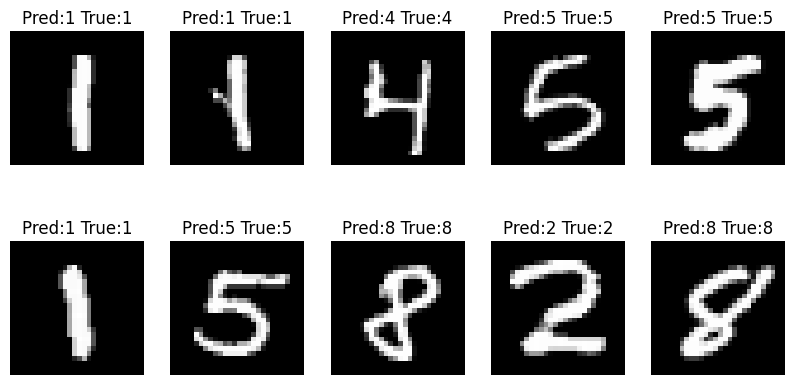

In [12]:
# making predictions
import numpy as np

# getting one batch
images, labels = next(test_generator)

predictions = model.predict(images)

# showing predictions
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i in range(10):
    ax = axes[i//5, i%5]
    ax.imshow(images[i].squeeze(), cmap='gray')
    
    pred_label = np.argmax(predictions[i])
    true_label = np.argmax(labels[i])
    
    ax.set_title(f"Pred:{pred_label} True:{true_label}")
    ax.axis("off")

plt.show()

**Exercise** 
1. Create 10 digit images (0–9). Draw them yourself and save as PNG/JPG. Preprocess each image accordingly and run predictions using your trained model. What is the model's performance?
2. Using the Fashion MNIST dataset, load and preprocess the data. Use the same CNN architecture from the MNIST exercise. Train the model for 5 epochs. Report model performance. (Use accuracy and F1 score)